# Prediksi Customer Lifetime Value (CLV) — Capstone Project

[Data CLV Prediction](https://drive.google.com/file/d/1pYhQb2WcbwLAaMF4FPIEJSM34O-1A4v8/view?usp=sharing)

**Analytic Approach:** Regresi

**Target variable:** `Customer Lifetime Value` (numerik, kontinu)


## 1. Business Problem & Data Understanding

### 1.1 Stakeholder
Stakeholder utama : **tim Marketing & Customer Retention**.
Tim ini bertanggung jawab menentukan:
- (1) Pelanggan mana yang menjadi prioritas lebih tinggi untuk mendapat penawaran retensi, kampanye upsell, dan investasi loyalitas.
- (2) Pelanggan mana yang menjadi prioritas lebih rendah.

### 1.2 Business Problem
Saat ini, tim Marketing & Customer Retention **tidak dapat mengetahui expected lifetime value seorang pelanggan sampai nilai tersebut sudah terakumulasi berdasarkan data billing dan klaim historis**. Hal ini menyulitkan pengambilan keputusan, baik pada saat akuisisi maupun renewal, mengenai pelanggan mana yang layak mendapat budget retensi.

- **Specific:** Tim belum memiliki cara untuk mengestimasi CLV seorang pelanggan menggunakan informasi yang tersedia *sebelum* nilai jangka panjangnya teramati (misalnya tipe polis, coverage, perilaku klaim, income, dan demografi).
- **Measurable:** Saat ini belum ada estimasi prediktif untuk CLV sama sekali melainkan hanya nilai historis yang sudah terealisasi. Keberhasilan diukur dari estimasi CLV dengan error yang cukup kecil untuk digunakan dalam alokasi budget (definisi kuantitatif "cukup kecil" akan dibahas di Section 6, setelah kita bisa membandingkannya dengan skala natural CLV pada data).

### 1.3 Mengapa Ini Penting
Alokasi budget marketing menjadi kurang efisien, yang terjadi adalah ***over-spend* untuk pelanggan yang bernilai rendah**, dan ***under-spend* untuk mempertahankan pelanggan yang high-value**. Prediksi CLV memungkinkan tim untuk **me-ranking dan mensegmentasi pelanggan berdasarkan expected value**, lalu mengalokasikan budget retensi/marketing tepat sasaran, ini menjadi salah satu cara untuk meningkatkan ROI marketing.

### 1.4 Goal
Goal yang Specific, Measurable, Achievable: **Membangun model regresi yang memprediksi `Customer Lifetime Value`** berdasarkan atribut polis, klaim, dan demografi pelanggan, dengan prediction error (MAE) yang cukup rendah, *relatif terhadap sebaran CLV pada data*, sehingga dapat diandalkan **untuk mengelompokkan pelanggan ke dalam tier prioritas** (misalnya top 20% vs bottom 20%) untuk prioritisasi marketing. Goal ini dianggap tercapai jika **R² model jelas mengungguli baseline naif / tebakan** (memprediksi rata-rata untuk semua orang), dan MAE jauh lebih kecil dibanding standar deviasi CLV.

### 1.5 Data Understanding — Arti Setiap Kolom

| Kolom | Arti dari Sisi Bisnis |
|---|---|
| `Vehicle Class` | Tipe/tier kendaraan yang diasuransikan (mis. Two-Door Car, SUV, Luxury Car) — proxy untuk nilai aset dan profil risiko pelanggan |
| `Coverage` | Tier paket asuransi yang dibeli pelanggan: Basic, Extended, atau Premium — proxy seberapa besar kesediaan pelanggan membayar untuk perlindungan |
| `Renew Offer Type` | Jenis penawaran/promosi renewal yang ditawarkan ke pelanggan — mencerminkan histori engagement marketing |
| `EmploymentStatus` | Status pekerjaan pelanggan (Employed, Retired, Unemployed, Disabled, Medical Leave) — proxy stabilitas finansial |
| `Marital Status` | Married, Single, atau Divorced — segmen demografi |
| `Education` | Tingkat pendidikan tertinggi — segmen demografi/sosioekonomi |
| `Number of Policies` | Jumlah polis yang dimiliki pelanggan di perusahaan ini — sinyal langsung kedalaman relasi/cross-sell |
| `Monthly Premium Auto` | Nominal yang dibayar pelanggan per bulan untuk asuransi mobil — sinyal revenue langsung |
| `Total Claim Amount` | Total nominal klaim yang sudah diajukan pelanggan — sinyal cost langsung |
| `Income` | Pendapatan tahunan pelanggan — proxy daya beli |
| `Customer Lifetime Value` (**target**) | Nilai yang kita prediksi: total expected profit dari pelanggan tersebut selama masa hubungannya dengan perusahaan |

Setiap baris merepresentasikan **satu pelanggan**, dijelaskan melalui demografi, konfigurasi polis, dan histori klaim, beserta CLV yang dihasilkan.


## 2. Import Library

In [ ]:
# =========================================================
# 1. LIBRARY UTAMA PEMROSESAN DATA & VISUALISASI
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 2. LIBRARY MACHINE LEARNING (SKLEARN)
# =========================================================
# A. Pembagian Data
from sklearn.model_selection import train_test_split # Fungsi untuk membagi data menjadi Data Latih (Train) dan Data Uji (Test)

# B. Preprocessing & Pipeline
from sklearn.compose import ColumnTransformer # Mengaplikasikan transformasi (scaling/encoding) yang berbeda pada kolom yang berbeda
from sklearn.pipeline import Pipeline # Membungkus alur kerja (preprocessing + model) menjadi satu kesatuan yang rapi

# C. Rekayasa Fitur (Feature Encoding & Scaling)
from sklearn.preprocessing import (OneHotEncoder, # Mengubah variabel kategorikal acak/nominal menjadi angka biner (0/1)
  StandardScaler, # Mengubah variabel kategorikal berjenjang/bertingkat menjadi angka berurutan (0, 1, 2, ...)
  OrdinalEncoder # Mengubah skala data numerik agar memiliki mean=0 dan std=1 (Standardisasi)
)

# D. Algoritma Model Regresi
from sklearn.linear_model import LinearRegression # Model acuan/pembanding paling dasar (biasa memprediksi dari nilai rata-rata)
from sklearn.ensemble import (RandomForestRegressor, # Algoritma gabungan banyak pohon keputusan secara acak (Bagging)
  GradientBoostingRegressor # Algoritma pohon keputusan canggih berurutan (Boosting)
)

# E. Metrik Evaluasi Model
# Algoritma regresi linear standar (mencari garis lurus terbaik)
from sklearn.metrics import (mean_squared_error, # MSE/RMSE: Menghitung rata-rata kuadrat selisih (memberi penalti lebih pada error besar)
  mean_absolute_error, # MAE: Menghitung rata-rata selisih mutlak antara prediksi dan nilai asli
  mean_absolute_percentage_error, # MAPE: Menghitung persentase rata-rata error
  r2_score # R²: Menghitung seberapa baik model menjelaskan variasi data (skor mendekati 1.0 = makin bagus)
)

# =========================================================
# 3. PENGATURAN TAMPILAN (SETUP & STYLING)
# =========================================================

from sklearn.dummy import DummyRegressor

sns.set_style("whitegrid") # Mengatur tema visualisasi grafik agar memiliki latar belakang garis-garis putih (lebih bersih dan rapi)
pd.set_option("display.max_columns", None) # Memaksa Pandas menampilkan SELURUH kolom pada DataFrame tanpa disembunyikan/dipotong tanda titik-titik (...)

## 3. Load Data
Pada bagian ini akan dilakukan:
- Pengambilan data pelanggan asuransi dari file `data_customer_lifetime_value.csv`.

- Cek Ukuran Data `df.shape`: `jumlah pelanggan` 5.669 baris dan `informasi/fitur` 11 kolom.

- Intip Data `df.head()`: Menampilkan 5 baris pertama sebagai sampel untuk melihat isi kolom-kolomnya, seperti: jenis kendaraan, tipe asuransi, status kerja, pendapatan, hingga nilai Customer Lifetime Value.

In [ ]:
# =========================================================
# 1. MEMBACA DATASET DARI FILE CSV
# =========================================================
# pd.read_csv() digunakan untuk mengimpor/membaca file CSV dan mengubahnya menjadi bentuk tabel (DataFrame Pandas).
# Pastikan file "data_customer_lifetime_value.csv" berada di folder/direktori yang sama dengan berkas Python ini.
df = pd.read_csv("data_customer_lifetime_value.csv")

# =========================================================
# 2. MENGECEK DIMENSI (UKURAN) DATAFRAME
# =========================================================
# df.shape menghasilkan output berupa tuple: (jumlah_baris, jumlah_kolom)
# Ini berguna untuk mengetahui seberapa banyak data pelanggan (baris) dan variabel/fitur (kolom) yang kita miliki.
print(df.shape)

# =========================================================
# 3. MENAMPILKAN SAMPEL DATA TERATAS
# =========================================================
# df.head() secara default menampilkan 5 baris pertama dari tabel data.
# Ini berguna untuk mengintip/memeriksa struktur kolom, nama variabel, serta contoh isi datanya.
df.head()


(5669, 11)


,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


## 4. Exploratory Data Analysis (EDA)
Pada bagian ini ditampilkan:
- `Informasi/fitur` 11 kolom dataset.
- tipe data `object` untuk data teks / kategori (6 kolom).
- tipe data `float64` untuk data numerik (5 kolom).
- Jumlah pelanggan sebanyak **`5.669 non-null entries`** baris data lengkap tanpa nilai kosong.

In [ ]:
# =========================================================
# MENGECEK RINGKASAN STRUKTUR & TIPE DATA DATAFRAME
# =========================================================
# df.info() menyajikan ringkasan teknis dari data, meliputi:
# 1. Total jumlah baris (entries) dan kolom.
# 2. Nama setiap kolom beserta jumlah data yang TIDAK kosong (Non-Null Count).
# 3. Tipe data masing-masing kolom (object/teks, int64/angka bulat, float64/angka desimal).
# 4. Total penggunaan memori (RAM) oleh dataset ini.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle Class            5669 non-null   object 
 1   Coverage                 5669 non-null   object 
 2   Renew Offer Type         5669 non-null   object 
 3   EmploymentStatus         5669 non-null   object 
 4   Marital Status           5669 non-null   object 
 5   Education                5669 non-null   object 
 6   Number of Policies       5669 non-null   float64
 7   Monthly Premium Auto     5669 non-null   float64
 8   Total Claim Amount       5669 non-null   float64
 9   Income                   5669 non-null   float64
 10  Customer Lifetime Value  5669 non-null   float64
dtypes: float64(5), object(6)
memory usage: 487.3+ KB


In [ ]:
# =========================================================
# 1. MENGECEK JUMLAH DATA KOSONG (MISSING VALUES) PER KOLOM
# =========================================================
print("Missing Value per Kolom:")

# df.isnull() mengubah seluruh sel data menjadi True (jika kosong) atau False (jika ada isinya).
# .sum() menjumlahkan nilai True tersebut untuk tiap kolom sehingga kita tahu berapa banyak data yang hilang.
print(df.isnull().sum())


# =========================================================
# 2. MENGHITUNG JUMLAH BARIS DATA DUPLIKAT
# =========================================================
# df.duplicated() mengecek apakah ada baris yang isinya persis sama dengan baris lain sebelumnya.
# .sum() menjumlahkan total baris yang terdeteksi sebagai duplikat.
duplikat = df.duplicated().sum()


# =========================================================
# 3. MENAMPILKAN HASIL DENGAN FORMAT PERSENTASE
# =========================================================
# Format {duplikat:,} memberi tanda koma ribuan pada angka.
# Format {duplikat/len(df)*100:.1f}% menghitung porsi duplikat terhadap total baris data (len(df)) dalam bentuk persentase (1 angka di belakang koma).
print(f"\nJumlah Baris yang duplikat: {duplikat:,} ({duplikat/len(df)*100:.1f}%)")

Missing Value per Kolom:
Vehicle Class              0
Coverage                   0
Renew Offer Type           0
EmploymentStatus           0
Marital Status             0
Education                  0
Number of Policies         0
Monthly Premium Auto       0
Total Claim Amount         0
Income                     0
Customer Lifetime Value    0
dtype: int64

Jumlah Baris yang duplikat: 618 (10.9%)


In [ ]:
# =========================================================
# MENAMPILKAN RINGKASAN STATISTIK DESKRIPTIF DATA NUMERIK
# =========================================================
# Sebaran data memperlihatkan bahwa mayoritas pelanggan berada di kelas menengah, tetapi ada beberapa pelanggan "sultan" (seperti pada Claim Amount dan CLV) yang nilainya jauh melampaui rata-rata pelanggan.

df.describe() # secara otomatis menghitung ringkasan statistik untuk seluruh kolom berjenis angka (numerik).


,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
count,5669.000000,5669.000000,5669.000000,5669.000000,5669.000000
mean,2.979361,93.026989,431.407103,37868.188569,8029.874592
std,2.393187,34.551795,287.558038,30490.490723,6916.708246
min,1.000000,61.000000,0.423310,0.000000,1898.007675
25%,1.000000,68.000000,266.932542,0.000000,3954.344534
50%,2.000000,82.000000,379.200000,34322.000000,5800.188903
75%,4.000000,109.000000,549.986128,62464.000000,9031.214859
max,9.000000,297.000000,2759.794354,99934.000000,83325.381190


### 4.1 Distribusi Target Variable


Skewness (raw): 3.06110718900048
Standar Deviasi CLV raw (benchmark error kita): 6916.7082456179905


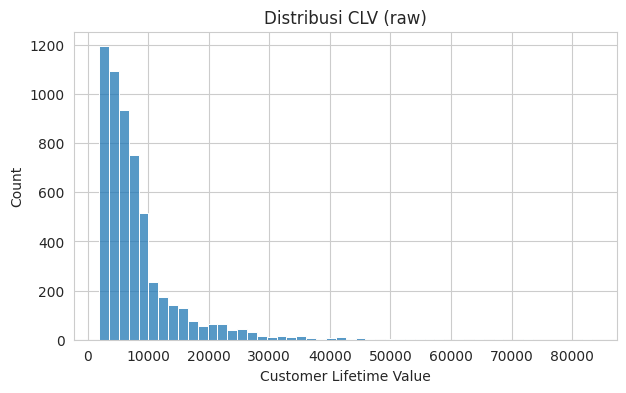

In [ ]:
# =========================================================
# 1. VISUALISASI DISTRIBUSI CLV DENGAN HISTOGRAM
# =========================================================
# Mempersiapkan area gambar/kanvas dengan ukuran 7x4 inci:
# 'fig' adalah objek gambar keseluruhan, 'ax' adalah sumbu tempat grafik digambar
fig, ax = plt.subplots(figsize=(7, 4))

# Membuat grafik histogram dari kolom 'Customer Lifetime Value':
# - df["Customer Lifetime Value"]: Kolom target yang ingin dilihat sebaran datanya
# - bins=50: Membagi rentang data CLV menjadi 50 batang interval
# - ax=ax: Menempatkan grafik histogram ke dalam kanvas yang sudah disiapkan di atas
sns.histplot(df["Customer Lifetime Value"], bins=50, ax=ax)

# Memberi judul pada grafik (penanda bahwa ini masih data mentah / belum ditransformasi)
ax.set_title("Distribusi CLV (raw)")


# =========================================================
# 2. MENGHITUNG NILAI STATISTIK KEMIRINGAN & STANDAR DEVIASI
# =========================================================
# .skew() menghitung tingkat kemiringan (skewness) distribusi data:
# - Jika nilainya > 1, artinya data menceng ke kanan (Right-Skewed) -> mayoritas bernilai rendah, ada sedikit yang nilainya tinggi sekali.
print("Skewness (raw):", df["Customer Lifetime Value"].skew())

# .std() menghitung Standar Deviasi (seberapa jauh variasi/sebaran nilai data dari rata-ratanya).
# Nilai std ini biasa dijadikan patokan awal/benchmark batas toleransi error model kita.
print("Standar Deviasi CLV raw (benchmark error kita):", df["Customer Lifetime Value"].std())


**CLV sangat right-skewed**, artinya mayoritas adalah pelanggan biasa dan hanya sejumlah kecil pelanggan bernilai sangat tinggi yang kemudian menarik ekor distribusi menjauh ke kanan. *Skew cenderung merugikan model linear (yang mengasumsikan error yang relatif simetris) lebih dari model berbasis tree, dan menjadi alasan untuk melihat versi log-transformed sebagai alternatif.*

### 4.2 Korelasi Fitur Numerik terhadap CLV

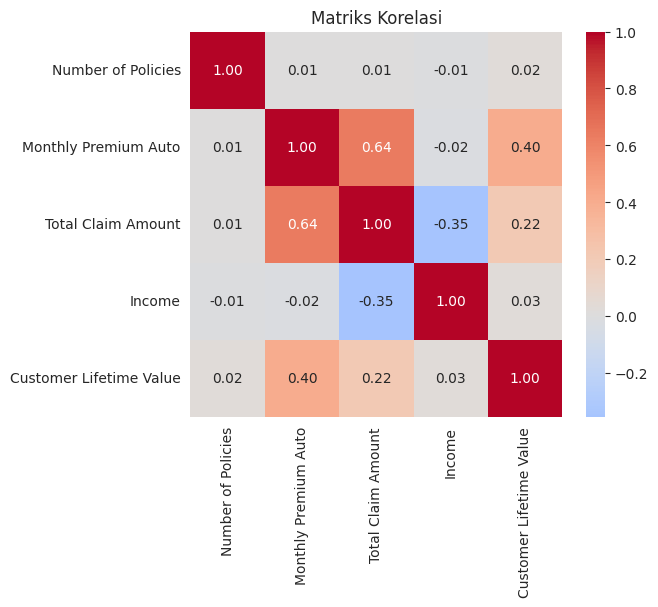

In [ ]:
# =========================================================
# 1. MEMILIH KOLOM NUMERIK UNTUK ANALISIS KORELASI
# =========================================================
# Membuat daftar (list) nama-nama kolom berjenis angka (numerik) yang ingin diukur hubungan antar variabelnya
numeric_cols = ["Number of Policies", "Monthly Premium Auto", "Total Claim Amount", "Income", "Customer Lifetime Value"]

# df[numeric_cols].corr() menghitung koefisien korelasi Pearson antara setiap pasangan kolom numerik tersebut.
# Hasilnya berupa tabel/matriks angka korelasi berkisar antara -1.0 sampai 1.0.
corr = df[numeric_cols].corr()


# =========================================================
# 2. VISUALISASI MATRIKS KORELASI DENGAN HEATMAP
# =========================================================
# Menyiapkan kanvas gambar dengan ukuran 6x5 inci
plt.figure(figsize=(6, 5))

# Membuat grafik peta panas (Heatmap) untuk memvisualisasikan matriks korelasi:
# - corr        : Data tabel korelasi yang akan divisualisasikan
# - annot=True  : Menampilkan angka koefisien korelasi langsung di dalam tiap kotak
# - fmt=".2f"   : Memformat angka desimal di dalam kotak menjadi 2 angka di belakang koma
# - cmap="coolwarm": Skema warna (Merah = korelasi positif kuat, Biru = korelasi negatif kuat)
# - center=0    : Menjadikan angka 0 sebagai titik tengah warna netral (putih/abu-abu)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriks Korelasi") # Memberi judul pada grafik
plt.show() # Menampilkan grafik secara utuh ke layar


**Interpretasi untuk feature selection:**
- **fitur numerik mentah berkorelasi lemah dengan CLV secara individual** (*semuanya di bawah ~0.4*), menunjukkan bahwa memang masalah non-linear. Ini juga berarti kita tidak punya masalah multicollinearity yang perlu diselesaikan, tidak ada dua fitur numerik yang berkorelasi tinggi satu sama lain, sehingga tidak perlu ada yang di-drop karena redundansi.

- `Monthly Premium Auto` adalah Prediktor Utama Terkuat ($r = 0.40$), premi bulanan adalah satu-satunya variabel yang memiliki korelasi linear paling signifikan dengan CLV secara individu. Semakin tinggi premi bulanan yang dibayarkan nasabah, cenderung semakin tinggi pula nilai total CLV mereka.

- `Total Claim Amount` memiliki korelasi lemah ($r = 0.22$), hubungan positifnya relatif kecil. Hal ini wajar terjadi karena Total Claim Amount sendiri berkorelasi sangat kuat dengan `Monthly Premium Auto` ($r = 0.64$), sehingga efeknya ke CLV sebagian besar merupakan turunan dari besarnya premi.

- `Income` ($r = 0.03$) dan `Number of Policies` ($r = 0.02$), secara individual tidak memiliki hubungan linear langsung dengan CLV. $Catatan Penting:$ Khusus untuk Number of Policies, meskipun secara linier mentah mendekati 0, pada bisnis asuransi variabel ini sering kali memiliki hubungan non-linear atau efek multiplikatif setelah dikombinasikan dengan premi (rumus dasar CLV umumnya sangat dipengaruhi oleh perkalian jumlah polis $\times$ nilai premi). $Kesimpulan Singkat:$ Jika hanya mengandalkan fitur numerik mentah secara linier dan individual, Monthly Premium Auto adalah satu-satunya fitur yang dominan dan paling relevan untuk memprediksi besarnya nilai CLV.

### 4.3 Fitur Kategorikal vs CLV

**Fitur yang Sangat Mempengaruhi CLV:**

`Vehicle Class`: Pemilik mobil Luxury SUV dan Luxury Car punya CLV tengah (median) yang jauh lebih tinggi dibanding pemegang mobil biasa (Four-Door / Two-Door).

`Coverage`: Makin lengkap polisnya (Premium > Extended > Basic), makin tinggi CLV-nya.

**Fitur yang Hampir Tidak Mempengaruhi CLV (Median Rata/Sama):**

`Renew Offer Type`, `EmploymentStatus`, `Marital Status`, dan `Education` semuanya punya garis tengah (median) CLV yang relatif sama rata di tiap kategori. Artinya, status pernikahan, pendidikan, jenis pekerjaan, maupun tipe penawaran tidak terlalu membedakan nilai CLV nasabah secara signifikan.

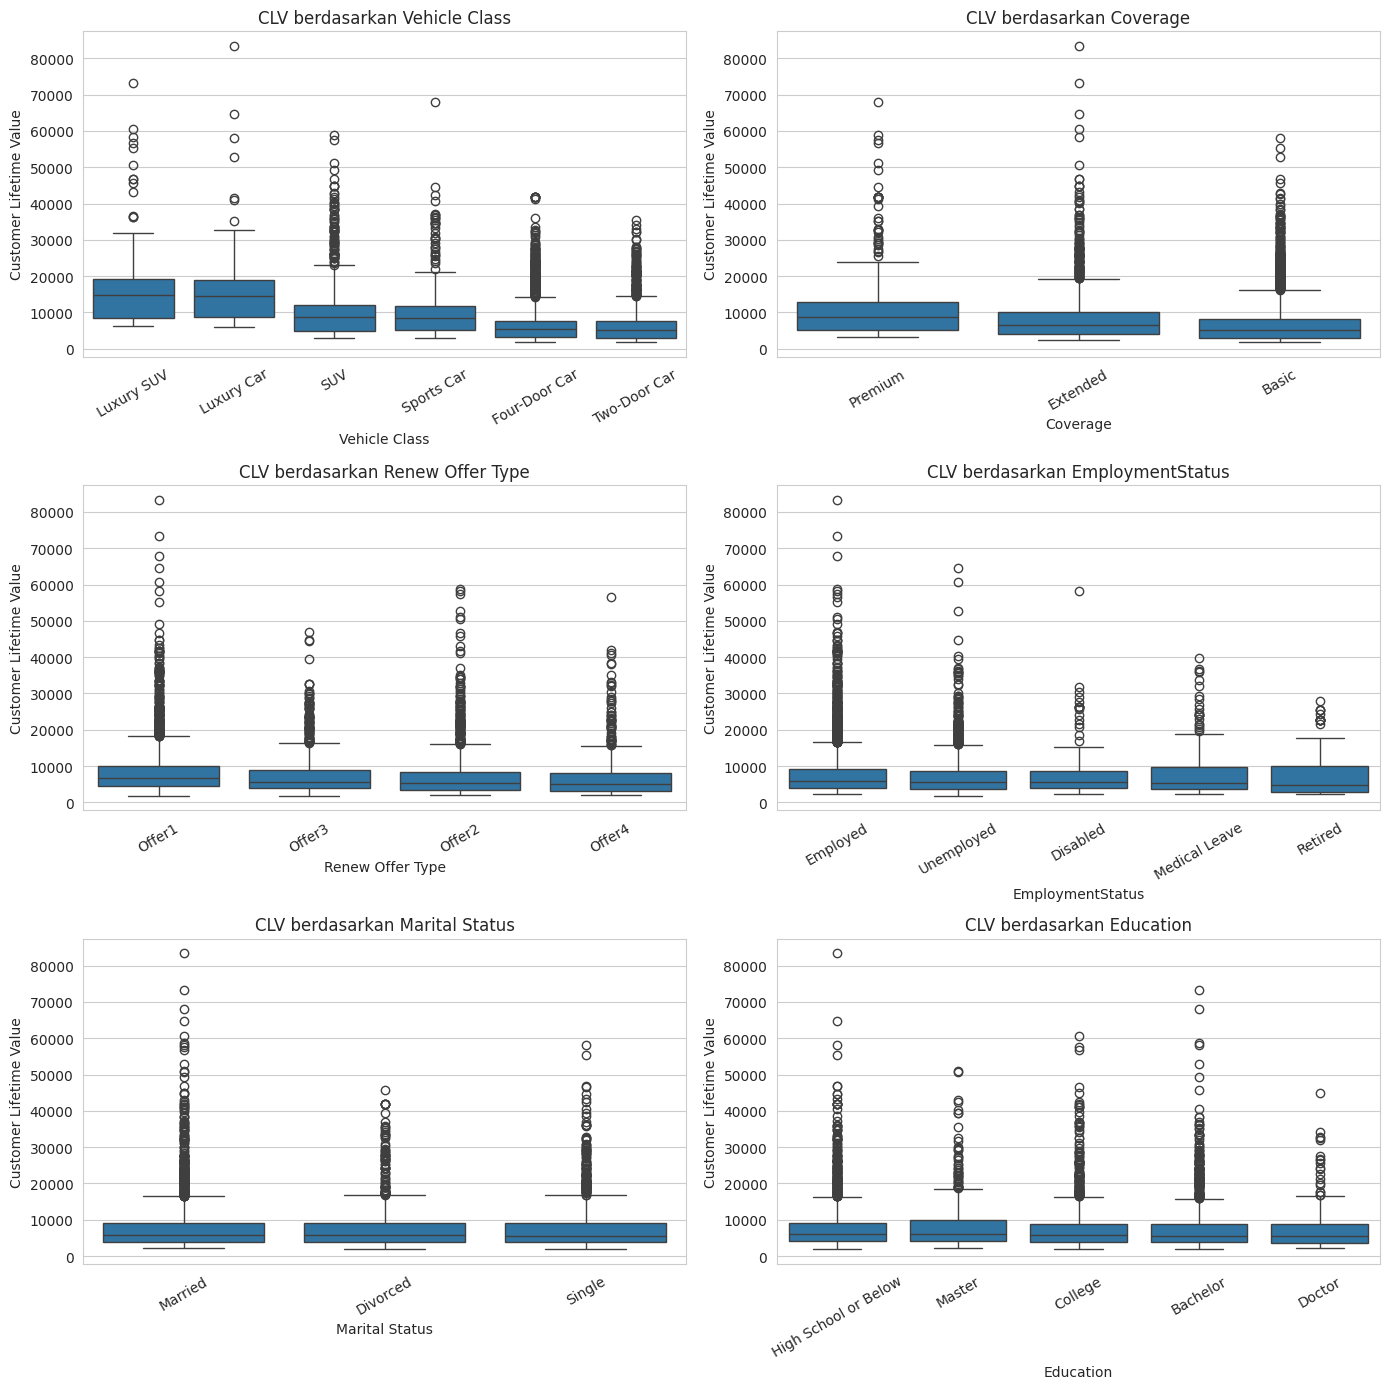

In [ ]:
# =========================================================
# 1. MENENTUKAN KOLOM KATEGORIKAL YANG INGIN DIANALISIS
# =========================================================
# Membuat daftar (list) nama-nama kolom bertipe teks/kategori yang akan dibuatkan grafik
categorical_cols = ["Vehicle Class", "Coverage", "Renew Offer Type", "EmploymentStatus", "Marital Status", "Education"]


# =========================================================
# 2. MENYIAPKAN GRID KANVAS GRAFIK (3 BARIS x 2 KOLOM)
# =========================================================
# Mempersiapkan area gambar berukuran total 14x14 inci yang berisi 6 subplot (3 baris x 2 kolom)
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# .flatten() meratakan matriks grid 2D (3x2) menjadi array 1D (panjang 6)
# Ini dilakukan agar kita bisa mengakses tiap subplot secara berurutan dengan mudah (axes[0], axes[1], dst.)
axes = axes.flatten()


# =========================================================
# 3. PERULANGAN (LOOP) UNTUK MEMBUAT BOXPLOT MASA-MASING KOLOM
# =========================================================
# enumerate() mengembalikan indeks urutan (i) dan nama kolom (col) secara bersamaan
for i, col in enumerate(categorical_cols):

    # Mengurutkan kategori berdasarkan nilai MEDIAN dari CLV (dari yang tertinggi ke terendah).
    # Pengurutan ini membuat grafik boxplot lebih rapi dan mudah dibandingkan antar kategorinya.
    order = df.groupby(col)["Customer Lifetime Value"].median().sort_values(ascending=False).index

    # Membuat Boxplot pada subplot ke-i:
    # - data=df: Dataset yang digunakan
    # - x=col: Variabel kategorikal di sumbu datar (X)
    # - y="Customer Lifetime Value": Nilai target CLV di sumbu tegak (Y)
    # - order=order: Mengatur urutan kategori di sumbu X sesuai hasil pengurutan median di atas
    # - ax=axes[i]: Menempatkan boxplot ke dalam subplot/posisi kanvas ke-i
    sns.boxplot(data=df, x=col, y="Customer Lifetime Value", order=order, ax=axes[i])

    # Memberi judul spesifik untuk masing-masing subplot
    axes[i].set_title(f"CLV berdasarkan {col}")

    # Memutar label teks pada sumbu X sebesar 30 derajat agar tulisan kategori tidak saling menumpuk
    axes[i].tick_params(axis="x", rotation=30)


# =========================================================
# 4. FINISHING TAMPILAN GRAFIK
# =========================================================
# plt.tight_layout() mengatur jarak antar subplot secara otomatis agar judul dan label sumbu tidak bertabrakan
plt.tight_layout()

# Menampilkan seluruh grafik secara utuh ke layar
plt.show()


## 5. Data Cleaning, Feature Selection, & Feature Engineering

### 5.1 Data Cleaning
**Tidak ada missing value** namun ada data duplikat sehingga kita perlu menghapus data duplikat terlebih dahulu.

In [ ]:
# Duplicate Cleaning
data_before = df.shape[0] # Jumlah data sebelum dihapus duplikat
df = df.drop_duplicates().reset_index(drop=True)
data_after = df.shape[0] # Jumlah data setelah dihapus duplikat
print(f"Menghapus {data_before - data_after} data duplikat -> Setelah dihapus maka data final sebanyak: {data_after} baris")

Menghapus 618 data duplikat -> Setelah dihapus maka data final sebanyak: 5051 baris



### 5.2 Feature Engineering
Karena Section 4.2 menunjukkan korelasi linear yang lemah antara fitur mentah individual dengan CLV, kita membuat beberapa **fitur rasio dan turunan** yang lebih merepresentasikan hubungan bisnis yang sebenarnya relevan bagi perusahaan asuransi:

- **`Claim_to_Premium_Ratio`** = Total Claim Amount / Monthly Premium Auto → proxy loss-ratio. Pelanggan yang banyak klaim relatif terhadap yang mereka bayar adalah pelanggan yang lebih costly, sehingga seharusnya menurunkan CLV.
- **`Premium_to_Income_Ratio`** = Monthly Premium Auto / (Income / 12) → keterjangkauan (affordability). Seberapa besar porsi income bulanan yang digunakan untuk premium — rasio tinggi bisa berarti pelanggan lebih price-sensitive dan berpotensi retensi lebih rendah.
- **`Policies_per_Claim_Dollar`** = Number of Policies / (Total Claim Amount + 1) → kedalaman relasi relatif terhadap cost (`+1` untuk menghindari pembagian dengan nol).
- **`Is_High_Value_Vehicle`** = 1 jika Vehicle Class termasuk Luxury Car, Luxury SUV, atau Sports Car, selain itu 0 → menyederhanakan 6 kategori kendaraan menjadi flag "aset bernilai tinggi" yang lebih bermakna secara bisnis.
- **`Coverage_Level`** = Coverage di-encode ulang sebagai ordinal 1/2/3 (Basic < Extended < Premium), bukan one-hot, karena tier coverage memiliki urutan alami — ini mempertahankan informasi urutan tersebut untuk model, alih-alih memperlakukan ketiga tier sebagai kategori yang tidak berhubungan.

Fitur mentah aslinya tetap dipertahankan berdampingan dengan fitur baru ini — model berbasis tree tetap bisa menggunakan keduanya tanpa masalah, dan kita bisa mengecek feature importance untuk melihat apakah fitur hasil engineering ini memang layak dipertahankan.


In [ ]:
# ==================================================================
# 1. DUPLIKASI DATAFRAME UNTUK REKAYASA FITUR (FEATURE ENGINEERING)
# ==================================================================
# Membuat salinan/copy DataFrame 'df' dengan nama 'df_fe'
# Ini dilakukan agar data mentah asli tetap aman dan tidak rusak jika terjadi kesalahan pengolahan
# Sebaran data MASIH MEMPERLIHATKAN bahwa mayoritas pelanggan berada di kelas menengah, tetapi ada beberapa pelanggan "sultan" yang nilainya jauh melampaui rata-rata pelanggan.
#         *seperti pada Premium_to_Income_Ratio, Is_High_Value_Vehicle, dan Policies_per_Claim_Dollar
df_fe = df.copy()


# =====================================================
# 2. PEMBUATAN FITUR-FITUR BARU (FEATURE ENGINEERING)
# =====================================================

# A. Rasio Klaim terhadap Premi Bulanan (Claim_to_Premium_Ratio)
# Menghitung berapa kali lipat jumlah klaim yang diajukan dibanding premi bulanan yang dibayar.
# Nilai tinggi = Pelanggan yang "menguras" asuransi/berisiko tinggi.
df_fe["Claim_to_Premium_Ratio"] = df_fe["Total Claim Amount"] / df_fe["Monthly Premium Auto"]

# B. Rasio Premi Bulanan terhadap Pendapatan Bulanan (Premium_to_Income_Ratio)
# Menghitung seberapa besar porsi gaji/pendapatan bulanan yang dipakai untuk bayar premi asuransi mobil:
# 1. (df_fe["Income"] / 12) -> Mengubah pendapatan tahunan menjadi pendapatan bulanan.
# 2. .replace(0, np.nan) -> Mencegah error "division by zero" (pembagian angka 0) jika pelanggan tidak punya pendapatan (Income = 0).
df_fe["Premium_to_Income_Ratio"] = df_fe["Monthly Premium Auto"] / (df_fe["Income"] / 12).replace(0, np.nan)
# 3. .fillna(...) -> Mengisi nilai kosong (NaN) hasil pembagian angka 0 tadi dengan nilai tengah (Median) rasio ini.
df_fe["Premium_to_Income_Ratio"] = df_fe["Premium_to_Income_Ratio"].fillna(df_fe["Premium_to_Income_Ratio"].median())

# C. Jumlah Polis per Nilai Klaim (Policies_per_Claim_Dollar)
# Menghitung proporsi jumlah polis yang dimiliki dibanding total klaimnya.
# Penambahan angka +1 di pembagi (Total Claim Amount + 1) adalah teknik "Laplace Smoothing"
# agar pembagian tidak crash/error ketika nilai klaim bernilai 0.
df_fe["Policies_per_Claim_Dollar"] = df_fe["Number of Policies"] / (df_fe["Total Claim Amount"] + 1)

# D. Fitur Penanda Kendaraan Mewah (Is_High_Value_Vehicle)
# Mengelompokkan kelas kendaraan bernilai tinggi ("mewah"):
luxury_classes = ["Luxury Car", "Luxury SUV", "Sports Car"]

# .isin(luxury_classes) mengecek apakah kelas kendaraan masuk dalam daftar mewah (True/False).
# .astype(int) mengubah hasil True menjadi angka 1 dan False menjadi angka 0 (fitur biner).
df_fe["Is_High_Value_Vehicle"] = df_fe["Vehicle Class"].isin(luxury_classes).astype(int)

# E. Tingkat Cakupan Perlindungan (Coverage_Level) - Encoding Ordinal
# Mengubah teks tingkatan perlindungan menjadi angka berurutan/berjenjang sesuai hirarkinya:
coverage_order = {"Basic": 1, "Extended": 2, "Premium": 3}

# .map() mengganti nilai teks pada kolom 'Coverage' sesuai kamus pemetaan (dictionary) di atas
df_fe["Coverage_Level"] = df_fe["Coverage"].map(coverage_order)


# ====================================================
# 3. RINGKASAN STATISTIK DESKRIPTIF FITUR-FITUR BARU
# ====================================================
# Menampilkan statistik dasar (mean, median/50%, min, max) dari fitur-fitur baru yang telah dibuat
# Hasilnya menunjukkan bahwa mayoritas pelanggan berada di kelas menengah,
# namun terdapat beberapa pelanggan "sultan" (outlier) yang nilainya jauh melampaui rata-rata.
df_fe[["Claim_to_Premium_Ratio", "Premium_to_Income_Ratio", "Policies_per_Claim_Dollar",
       "Is_High_Value_Vehicle", "Coverage_Level"]].describe()


,Claim_to_Premium_Ratio,Premium_to_Income_Ratio,Policies_per_Claim_Dollar,Is_High_Value_Vehicle,Coverage_Level
count,5669.000000,5669.000000,5669.000000,5669.000000,5669.000000
mean,4.579009,0.027871,0.018946,0.093315,1.472747
std,2.259416,0.020101,0.083994,0.290898,0.649227
min,0.003010,0.007340,0.000362,0.000000,1.000000
25%,3.231617,0.016631,0.002967,0.000000,1.000000
50%,4.800000,0.022607,0.005975,0.000000,1.000000
75%,5.593370,0.031118,0.013885,0.000000,2.000000
max,12.107034,0.227572,2.542308,1.000000,3.000000


### 5.3 Feature Selection
Setelah fitur hasil engineering ditambahkan, kita mengecek korelasinya terhadap CLV untuk memastikan fitur-fitur ini menambah sinyal di luar fitur mentah. Ini adalah pengecekan feature *selection* kita (menentukan mana yang layak masuk model dan mana yang redundan).


In [ ]:
# =========================================================
# 1. MENENTUKAN LIST KOLOM NUMERIK (TERMASUK FITUR BARU)
# =========================================================
# Membuat daftar nama-nama kolom numerik asli gabungan dengan fitur-fitur baru hasil rekayasa (Feature Engineering)
fe_numeric = ["Number of Policies", "Monthly Premium Auto", "Total Claim Amount", "Income",
              "Claim_to_Premium_Ratio", "Premium_to_Income_Ratio", "Policies_per_Claim_Dollar",
              "Is_High_Value_Vehicle", "Coverage_Level", "Customer Lifetime Value"] # Variabel Target


# =========================================================
# 2. MENGHITUNG DAN MENGURUTKAN KORELASI TERHADAP TARGET CLV
# =========================================================
# df_fe[fe_numeric].corr():
# Menghitung tabel/matriks korelasi untuk seluruh kolom numerik di atas.
#
# ["Customer Lifetime Value"]:
# Mengambil / mengisolasi hasil korelasi seluruh fitur HANYA terhadap variabel target 'Customer Lifetime Value'.
#
# .sort_values(ascending=False):
# Mengurutkan nilai korelasi dari yang paling positif/tertinggi (paling berpengaruh searah)
# hingga yang paling negatif/terendah.
corr_fe = df_fe[fe_numeric].corr()["Customer Lifetime Value"].sort_values(ascending=False)

# Menampilkan hasil urutan korelasi ke layar
corr_fe


,Customer Lifetime Value
Customer Lifetime Value,1.000000
Monthly Premium Auto,0.402297
Is_High_Value_Vehicle,0.263144
Total Claim Amount,0.215354
Coverage_Level,0.175497
Premium_to_Income_Ratio,0.165722
Income,0.025698
Number of Policies,0.024721
Claim_to_Premium_Ratio,-0.015675
Policies_per_Claim_Dollar,-0.015863


Semua fitur hasil engineering dipertahankan untuk tahap modeling karena tidak ada yang merupakan duplikat murni dari kolom yang sudah ada (dicek lewat matriks korelasi, **tidak ada pasangan yang melebihi 0.9**), dan model berbasis tree secara natural akan memberi bobot rendah pada fitur yang tidak membantu. Kontribusi sebenarnya akan dikonfirmasi lewat feature importance di Section 8, setelah model dilatih. Ini sinyal seleksi yang lebih bisa diandalkan untuk model non-linear dibanding korelasi saja, karena korelasi hanya menangkap hubungan linear.


### 5.4 Feature Set Final

Train-Test Split

In [ ]:
# =========================================================
# 1. MENENTUKAN TARGET DAN FITUR-FITUR
# =========================================================
# Target adalah variabel utama yang ingin kita tebak/prediksi harganya oleh model Machine Learning
target = "Customer Lifetime Value"

# Feature Numerik: Kolom berjenis angka yang akan langsung diproses/diskalakan
numeric_features = ["Number of Policies", "Monthly Premium Auto", "Total Claim Amount", "Income",
                     "Claim_to_Premium_Ratio", "Premium_to_Income_Ratio", "Policies_per_Claim_Dollar",
                     "Is_High_Value_Vehicle", "Coverage_Level"]

# Feature Kategorikal: Kolom bertipe teks/kategori yang nantinya perlu diubah ke angka (misal: One-Hot Encoding)
categorical_features = ["Vehicle Class", "Renew Offer Type", "EmploymentStatus", "Marital Status", "Education"]
# Catatan Penting: Kolom "Coverage" (teks) tidak dimasukkan ke sini lagi untuk menghindari redundansi (kebocoran data),
# karena nilainya sudah kita wakili secara hirarki ordinal lewat fitur baru "Coverage_Level" di numerik.


# =========================================================
# 2. MEMISAHKAN VARIABEL PREDIKTOR (X) DAN TARGET (y)
# =========================================================
# X berisi seluruh kolom fitur (input) yang dipakai model untuk belajar
X = df_fe[numeric_features + categorical_features]
# y berisi satu kolom target (output) yang ingin diprediksi oleh model
y = df_fe[target]


# =========================================================
# 3. MEMBAGI DATA MENJADI DATA LATIH (TRAIN) DAN DATA UJI (TEST)
# =========================================================
# train_test_split() membagi data secara acak menjadi dua bagian:
# - test_size=0.2 : Membagi 80% data untuk latihan (Train) dan 20% data untuk ujian (Test).
# - random_state=42 : Menjaga agar pembagian data secara acak ini SELALU KONSISTEN (dapat direproduksi ulang)
#                     tiap kali kode dijalankan.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran/dimensi baris dan kolom dari Data Latih dan Data Uji ke layar
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (4535, 14)  Test: (1134, 14)


Encoding Process

In [ ]:
# =========================================================
# MENYUSUN ALUR PEMROSESAN DATA OTOMATIS (COLUMNTRANSFORMER)
# =========================================================
# ColumnTransformer digunakan untuk menerapkan teknik pembersihan/pemrosesan
# data yang BERBEDA pada kelompok kolom yang BERBEDA secara bersamaan.
preprocessor = ColumnTransformer(
    transformers=[
        # 1. TRANSFORMASI KOLOM NUMERIK ("num")
        # - StandardScaler(): Mengubah skala data angka agar nilai rata-rata (mean) = 0
        #   dan variasi data (std dev) = 1, sehingga tidak ada fitur angka yang mendominasi hanya karena skalanya besar.
        # - numeric_features: Daftar kolom angka yang akan diskalakan.
        ("num", StandardScaler(), numeric_features),
        # 2. TRANSFORMASI KOLOM KATEGORIKAL ("cat")
        # - OneHotEncoder(): Mengubah nilai berupa teks/kategori menjadi kolom-kolom biner (angka 0 dan 1).
        # - handle_unknown="ignore": Mencegah program crash/error jika nanti pada data uji (test)
        #   muncul nilai kategori baru yang belum pernah dilihat saat latihan (training).
        # - categorical_features: Daftar kolom teks/kategori yang akan di-encode.
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


## 6. Analytics — Algorithm & Evaluation Metrics

### 6.1 Baseline
Sebelum membandingkan model sesungguhnya, kita menetapkan **baseline naif**: selalu memprediksi rata-rata CLV. Model apa pun yang kita bangun harus jelas mengungguli baseline ini agar layak digunakan.


In [ ]:
# =========================================================
# 1. MEMBUAT MODEL BASELINE / ACUAN DASAR (DUMMY REGRESSOR)
# =========================================================
# DummyRegressor adalah model "bodoh" yang tidak benar-benar belajar dari pola data.
# strategy="mean" artinya model ini HANYA menebak semua nilai target dengan angka rata-rata (mean) dari y_train.
# Tujuannya: Menjadi standar minimal. Model ML canggih kita NANTI HARUS BISA MENGAWALKAN skor baseline ini!
baseline = DummyRegressor(strategy="mean")

# Melatih model acuan pada data latih (hanya menghitung nilai rata-rata y_train)
baseline.fit(X_train, y_train)

# Memprediksi data uji (semua hasil tebakan akan persis sama, yaitu nilai rata-rata tadi)
baseline_preds = baseline.predict(X_test)


# =========================================================
# 2. MENGHITUNG METRIK EVALUASI KINERJA BASELINE
# =========================================================
# MAE (Mean Absolute Error): Rata-rata besarnya kesalahan tebakan dalam satuan mata uang/asli.
baseline_mae = mean_absolute_error(y_test, baseline_preds)

# RMSE (Root Mean Squared Error): Akar kuadrat dari MSE untuk mengukur error (memberi bobot/penalti lebih besar pada kesalahan ekstrem).
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

# =========================================================
# 3. MENAMPILKAN HASIL EVALUASI DENGAN FORMAT RAPI
# =========================================================
# R2 (R-Squared): Mengukur seberapa besar persentase variasi data target yang bisa dijelaskan model.
# Nilai R2 untuk model Dummy Regressor berbasis rata-rata biasanya mendekati 0.0 (atau bahkan negatif pada data uji).
print(f"Baseline (prediksi rata-rata) | MAE: {baseline_mae:.2f} | RMSE: {baseline_rmse:.2f} | R2: {r2_score(y_test, baseline_preds):.4f}")


Baseline (prediksi rata-rata) | MAE: 4446.74 | RMSE: 6655.63 | R2: -0.0002


### 6.2 Cara Kerja Masing-Masing Algoritma

- **Linear Regression** menghasilkan satu hubungan garis lurus (hyperplane): model mengestimasi bobot untuk setiap fitur lalu menjumlahkannya untuk memprediksi CLV. Cepat dan mudah diinterpretasi, tetapi mengasumsikan efek setiap fitur bersifat konstan dan aditif, tidak bisa menangkap efek "fitur ini lebih berpengaruh untuk segmen tertentu".

- **Random Forest Regressor** membangun banyak decision tree, masing-masing dilatih pada subset baris dan fitur secara acak, lalu hasil prediksinya dirata-ratakan. Setiap tree melakukan split berulang pada fitur/threshold yang paling baik memisahkan CLV tinggi vs rendah di titik tersebut. Merata-ratakan banyak tree mengurangi overfitting dibanding satu tree tunggal, dan secara natural menangkap hubungan non-linear serta interaksi antar fitur tanpa perlu kita tentukan secara eksplisit.

- **Gradient Boosting Regressor** juga membangun ensemble decision tree, tetapi alih-alih dilatih secara independen lalu dirata-ratakan, tree-tree tersebut dilatih **secara berurutan**, setiap tree baru dilatih khusus untuk mengoreksi error (residual) dari tree-tree sebelumnya. Biasanya menghasilkan akurasi lebih tinggi dari data yang sama dibanding Random Forest, dengan konsekuensi lebih rentan overfitting jika tidak di-tuning dengan hati-hati.

Kita memilih ketiga algoritma ini karena EDA kita (Section 4.2) menunjukkan korelasi *linear* yang lemah antara fitur individual dengan CLV — ini adalah sinyal kuat bahwa hubungan sebenarnya bersifat non-linear, sehingga kita mengharapkan model berbasis tree akan mengungguli Linear Regression, dan ekspektasi ini diuji langsung di bawah, bukan sekadar diasumsikan.

### 6.3 Alasan Pemilihan Evaluation Metrics

Untuk business problem ini kita menggunakan **MAE, RMSE, dan R²**:

- **MAE (Mean Absolute Error)** merupakan rata-rata error absolut dalam dolar. Ini adalah metric yang paling mudah dipahami dari sisi bisnis: "rata-rata, estimasi CLV kita meleset sebesar $X." Berguna untuk mengomunikasikan kualitas model ke stakeholder non-teknis seperti tim marketing.
- **RMSE (Root Mean Squared Error)**, mirip MAE tetapi memberi penalti lebih besar untuk error yang besar (dikuadratkan sebelum dirata-ratakan). Kita pantau metric ini berdampingan dengan MAE karena untuk CLV, salah estimasi secara signifikan (terlalu rendah atau terlalu tinggi) pada pelanggan bernilai *tinggi* lebih costly bagi bisnis dibanding sedikit meleset pada banyak pelanggan rata-rata, dimana RMSE menampilkan risiko ini, sedangkan MAE saja tidak.
- **R² (Coefficient of Determination)** merupakan seberapa besar variansi CLV yang bisa dijelaskan model, pada skala kurang lebih 0–1. Ini menunjukkan seberapa jauh kita lebih baik dibanding sekadar menebak rata-rata, yang berhubungan langsung dengan goal "measurable" kita di Section 1.4.

Kita tidak menggunakan MAPE di sini karena metric ini menjadi tidak stabil/menyesatkan ketika target bersifat skewed dengan sejumlah nilai yang sangat kecil relatif terhadap nilai terbesar (pembagian dengan nilai CLV yang kecil membuat persentase error membengkak secara tidak proporsional). Ini adalah pitfall yang sudah dikenal untuk target moneter yang right-skewed seperti CLV.


In [ ]:
# =========================================================
# 1. MENDEFINISIKAN BEBERAPA ALGORITMA MODEL
# =========================================================
# Kita membuat dictionary untuk menyimpan daftar model yang ingin dibandingkan:
# - Linear Regression : Algoritma dasar yang mencari hubungan garis lurus.
# - Random Forest     : Algoritma berbasis gabungan banyak pohon keputusan (300 pohon). n_jobs=-1 memakai semua inti CPU agar cepat.
# - Gradient Boosting : Algoritma pohon keputusan berurutan yang saling memperbaiki kesalahan dari pohon sebelumnya.
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

# Tempat menyimpan hasil evaluasi, pipeline, dan prediksi dari setiap model
results = {}


# =========================================================
# 2. MELAKUKAN ITERASI (LOOPING) UNTUK MELATIH & EVALUASI
# =========================================================
# Loop akan mengambil pasangan 'nama_model' dan 'objek_model' satu per satu
for name, model in models.items():

    # Membungkus Preprocessing dan Model ke dalam 1 kesatuan Pipeline
    # Ini memastikan data diolah otomatis secara rapi sebelum masuk ke model tanpa ada kebocoran data (data leakage)
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

    # Melatih (Train) seluruh alur pipeline pada Data Latih
    pipe.fit(X_train, y_train)

    # Memprediksi hasil tebakan pada Data Uji
    preds = pipe.predict(X_test)

    # Menghitung metrik-metrik performa evaluasi:
    mae = mean_absolute_error(y_test, preds) # Rata-rata selisih error mutlak
    rmse = np.sqrt(mean_squared_error(y_test, preds)) # Akar rata-rata kuadrat error
    r2 = r2_score(y_test, preds) # Skor ketepatan model (0.0 - 1.0)

    # Menyimpan seluruh informasi penting tiap model ke dalam dictionary 'results'
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "pipeline": pipe, "preds": preds}

    # Menampilkan ringkasan hasil evaluasi ke layar dengan format tabel rapi
    # :20s = spasi selebar 20 karakter teks | :9.2f = format angka desimal 2 angka di belakang koma dengan lebar 9 karakter
    print(f"{name:20s} | MAE: {mae:9.2f} | RMSE: {rmse:9.2f} | R2: {r2:.4f}")


Linear Regression    | MAE:   3859.06 | RMSE:   6346.19 | R2: 0.1539
Random Forest        | MAE:   1626.77 | RMSE:   4069.63 | R2: 0.6520
Gradient Boosting    | MAE:   1693.56 | RMSE:   3948.63 | R2: 0.6724


### 6.4 Perbandingan Model (vs Baseline)

In [ ]:
# 1. Mengubah dictionary hasil evaluasi model menjadi DataFrame (tabel)
# Variabel 'results' berisi hasil performa tiap model (MAE, RMSE, R2)
results_df = pd.DataFrame({
    name: {"MAE": r["MAE"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for name, r in results.items()
})

# 2. Menambahkan model pembanding dasar/sederhana (Baseline) ke dalam tabel
# Baseline ini menghitung seberapa akurat jika kita cuma menebak menggunakan nilai rata-rata (mean)
results_df["Baseline (mean)"] = [baseline_mae, baseline_rmse, r2_score(y_test, baseline_preds)]

# 3. Merapikan tampilan tabel:
# - .T (Transpose): Memutar posisi tabel agar Nama Model jadi Baris, dan Evaluasi (MAE, RMSE, R2) jadi Kolom
# - .sort_values("R2", ascending=False): Mengurutkan model dari yang R2-nya tertinggi (paling bagus) ke terendah
results_df = results_df.T.sort_values("R2", ascending=False)

# 4. Menampilkan tabel hasil akhir
results_df


,MAE,RMSE,R2
Gradient Boosting,1693.562102,3948.625526,0.672424
Random Forest,1626.771888,4069.631119,0.652039
Linear Regression,3859.064331,6346.188182,0.153852
Baseline (mean),4380.390037,6909.985222,-0.003170


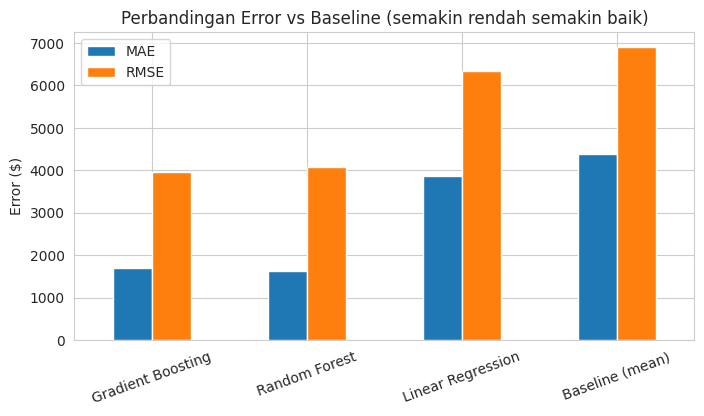

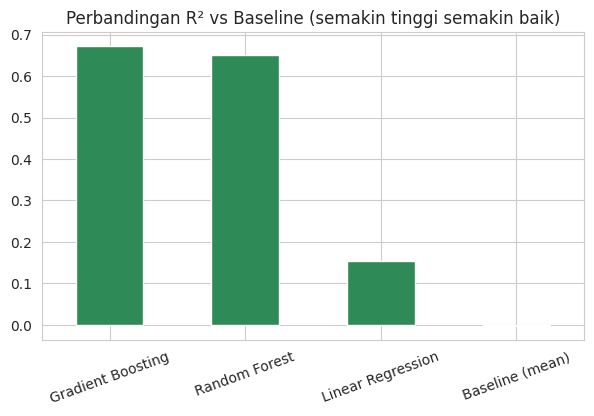

In [ ]:
#=========================================================
# 1. VISUALISASI PERBANDINGAN ERROR (MAE & RMSE)
# =========================================================
# Mengambil kolom 'MAE' dan 'RMSE' dari DataFrame untuk dibuatkan diagram batang
results_df[["MAE", "RMSE"]].plot(
    kind="bar", # Jenis visualisasi: Diagram Batang (Bar Chart)
    figsize=(8,4), # Ukuran kanvas grafik: Lebar 8 inci, Tinggi 4 inci
    title="Perbandingan Error vs Baseline (semakin rendah semakin baik)" # Judul grafik
)

# Menamai sumbu tegak (Y) untuk menjelaskan nilai angka yang muncul
plt.ylabel("Error ($)") # Menginfokan bahwa sumbu Y adalah nilai kesalahan/error dalam satuan Dolar

# Merapikan tampilan label nama model pada sumbu datar (X)
plt.xticks(rotation=20) # Memutar posisi teks nama model 20 derajat miring agar tidak menumpuk & mudah dibaca

# Menampilkan grafik pertama (grafik Error) secara utuh ke layar
plt.show()


# =========================================================
# 2. VISUALISASI PERBANDINGAN AKURASI (R²)
# =========================================================
# Mengambil kolom 'R2' saja untuk melihat kemampuan prediksi tiap model
results_df["R2"].plot(
    kind="bar", # Jenis visualisasi: Diagram Batang (Bar Chart)
    figsize=(7,4), # Ukuran kanvas grafik: Lebar 7 inci, Tinggi 4 inci
    title="Perbandingan R² vs Baseline (semakin tinggi semakin baik)", # Judul grafik
    color="seagreen"# Mengubah warna batang menjadi hijau laut agar berbeda dari grafik error
)

# Merapikan label nama model di sumbu X untuk grafik kedua
plt.xticks(rotation=20) # Memutar teks nama model 20 derajat miring

# Menampilkan grafik kedua (grafik R²) secara utuh ke layar
plt.show()


Hasil pengujian 3 model **untuk pola data yang non-linear**  (Linear Regression, Random Forest, dan Gradient Boosting) **yang dibandingkan langsung dengan Baseline Naif (tebakan rata-rata) dengan menggunakan metrik MAE, RMSE, dan R2**.

Dimana hasilnya jelas mengungguli baseline mean-only, **artinya model ini jauh melampaui "sekadar menebak rata-rata"**, dan mengonfirmasi bahwa goal yang ditetapkan (peningkatan jelas dibanding baseline, dengan error jauh lebih kecil dari standar deviasi CLV) sudah tercapai.


## 7. Kapan Model Ini Bisa Dipercaya?

R²/MAE secara keseluruhan bisa menyembunyikan *di mana* model lebih atau kurang bisa diandalkan. Kita mengecek error model terbaik berdasarkan magnitude CLV dan segmen kunci, karena ini langsung menjawab pertanyaan stakeholder berikutnya: "apakah saya bisa percaya prediksi ini untuk pelanggan *ini*?"


In [ ]:
# =========================================================
# 1. MENENTUKAN MODEL TERBAIK (BERDASARKAN URUTAN SKOR R²)
# =========================================================
# Karena 'results_df' sudah diurutkan dari R² tertinggi, baris paling atas (indeks 0) adalah model terbaik.
# Kode di bawah ini mengambil nama model terbaik di urutan ke-0,
# TAPI jika urutan ke-0 adalah "Baseline (mean)", maka otomatis mengambil urutan ke-1 (model terbaik berikutnya).
best_name = results_df.index[0] if results_df.index[0] != "Baseline (mean)" else results_df.index[1]

# Mengambil objek pipeline (langkah pemrosesan & model) milik model terbaik dari dictionary 'results'
best_pipe = results[best_name]["pipeline"]

# Mengambil hasil nilai prediksi (y_pred) yang dihasilkan oleh model terbaik tersebut
best_preds = results[best_name]["preds"]

# =========================================================
# 2. MEMBUAT TABEL EVALUASI PREDIKSI (EVAL_DF)
# =========================================================
# Membuat salinan (copy) dari data uji (X_test) agar data aslinya tidak tertimpa/rusak
eval_df = X_test.copy()

# Menambahkan kolom nilai CLV asli (faktual) yang ada di data uji
eval_df["Actual_CLV"] = y_test.values

# Menambahkan kolom nilai CLV hasil tebakan/prediksi dari model terbaik
eval_df["Predicted_CLV"] = best_preds

# Menghitung selisih mutlak (Absolute Error) antara nilai asli vs nilai prediksi.
# .abs() digunakan agar hasilnya selalu bernilai positif (menghilangkan tanda minus jika prediksi kelebihi/kekurangan)
eval_df["Abs_Error"] = (eval_df["Actual_CLV"] - eval_df["Predicted_CLV"]).abs()

# =========================================================
# 3. MENAMPILKAN RINGKASAN STATISTIK EVALUASI
# =========================================================
# Mencetak nama model terbaik yang terpilih
print(f"Model terbaik: {best_name}")

# Menampilkan statistik deskriptif (mean, std, min, median, max) khusus untuk 3 kolom ini
# Ini berguna untuk melihat seberapa jauh selisih/error prediksi secara keseluruhan
eval_df[["Actual_CLV", "Predicted_CLV", "Abs_Error"]].describe()


Model terbaik: Gradient Boosting


,Actual_CLV,Predicted_CLV,Abs_Error
count,1011.000000,1011.000000,1011.000000
mean,7748.800643,7778.489028,1693.562102
std,6902.473731,5245.861061,3568.765679
min,1940.981221,1890.294200,0.507354
25%,3693.012200,3683.906175,113.280006
50%,5794.104234,5813.019885,271.776885
75%,8663.188144,11341.116983,1106.451427
max,73225.956520,32240.843597,40985.112923


CLV_Quartile
Q1 (terendah)      186.559359
Q2                 299.118145
Q3                1791.991679
Q4 (tertinggi)    5049.387216
Name: Abs_Error, dtype: float64


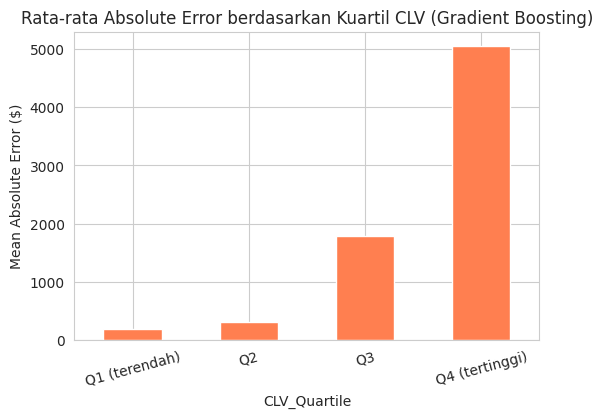

In [ ]:
# Error berdasarkan kuartil CLV — apakah model lebih buruk pada pelanggan bernilai tinggi?

# =========================================================
# 1. MENGELOMPOKKAN PELANGGAN BERDASARKAN KELOMPOK CLV (KUARTIL)
# =========================================================
# pd.qcut() membagi data 'Actual_CLV' menjadi 4 kelompok (kuartil) dengan jumlah sampel yang sama besar:
# - Q1: 25% pelanggan dengan nilai CLV terendah
# - Q2: 25% pelanggan menengah-bawah
# - Q3: 25% pelanggan menengah-atas
# - Q4: 25% pelanggan dengan nilai CLV tertinggi ("sultan")
eval_df["CLV_Quartile"] = pd.qcut(eval_df["Actual_CLV"], 4, labels=["Q1 (terendah)", "Q2", "Q3", "Q4 (tertinggi)"])

# =========================================================
# 2. MENGHITUNG RATA-RATA ERROR UNTUK SETIAP KELOMPOK CLV
# =========================================================
# .groupby() mengelompokkan data berdasarkan kuartilnya,
# lalu .mean() menghitung rata-rata besarnya kesalahan/error prediksi ('Abs_Error') di masing-masing kelompok tersebut
error_by_quartile = eval_df.groupby("CLV_Quartile", observed=True)["Abs_Error"].mean()

# Mencetak angka rata-rata error per kelompok ke layar
print(error_by_quartile)

# =========================================================
# 3. VISUALISASI DIAGRAM BATANG RATA-RATA ERROR PER KUARTIL
# =========================================================
# Membuat grafik batang untuk membandingkan tingkat error antar kelompok secara visual
error_by_quartile.plot(
    kind="bar", # Jenis grafik: Diagram Batang (Bar Chart)
    figsize=(6,4), # Ukuran kanvas grafik: Lebar 6 inci, Tinggi 4 inci
    color="coral", # Memberi warna jingga (coral) pada batang grafik
    title=f"Rata-rata Absolute Error berdasarkan Kuartil CLV ({best_name})" # Judul grafik (memuat nama model terbaik)
)

plt.ylabel("Mean Absolute Error ($)") # Menamai sumbu tegak (Y) untuk menjelaskan nilai error dalam satuan Dolar
plt.xticks(rotation=15) # Merapikan label sumbu datar (X) dengan memutar teks sebesar 15 derajat
plt.show() # Menampilkan grafik ke layar


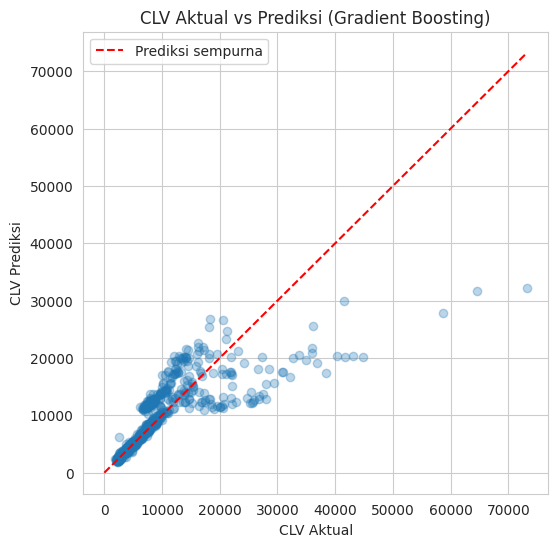

In [ ]:
# Scatter Actual vs Predicted — menunjukkan secara visual di mana model over/under-predict

# =========================================================
# 1. MEMBUAT SCATTER PLOT (AKTUALE VS PREDIKSI)
# =========================================================
# Menyiapkan kanvas gambar berbentuk persegi (lebar 6 inci, tinggi 6 inci)
plt.figure(figsize=(6,6))

# Membuat grafik titik (scatter plot) untuk membandingkan nilai asli vs tebakan model:
# - Sumbu X: Nilai CLV asli dari data (Actual_CLV)
# - Sumbu Y: Nilai CLV tebakan model (Predicted_CLV)
# - alpha=0.3: Mengatur transparansi titik (30%), agar jika banyak titik menumpuk di area yang sama tetap terlihat jelas
plt.scatter(eval_df["Actual_CLV"], eval_df["Predicted_CLV"], alpha=0.3)


# =========================================================
# 2. MEMBUAT GARIS REFERENSI "PREDIKSI SEMPURNA" (DIAGONAL)
# =========================================================
# Mencari nilai tertinggi dari data aktual maupun prediksi untuk menentukan batas panjang garis diagonal
max_val = max(eval_df["Actual_CLV"].max(), eval_df["Predicted_CLV"].max())

# Menggambar garis putus-putus merah (r--) dari koordinat (0,0) sampai (max_val, max_val):
# Garis ini adalah patokan "Ideal" -> Jika titik berada tepat di garis ini, artinya Prediksi == Aktual (Error = 0)
plt.plot([0, max_val], [0, max_val], "r--", label="Prediksi sempurna")


# =========================================================
# 3. MERAPIKAN LABEL DAN KETERANGAN GRAFIK
# =========================================================
plt.xlabel("CLV Aktual") # Memberi label sumbu datar (X)
plt.ylabel("CLV Prediksi") # Memberi label sumbu tegak (Y)
plt.title(f"CLV Aktual vs Prediksi ({best_name})") # Judul grafik (memuat nama model terbaik)
plt.legend() # Menampilkan kotak legenda untuk keterangan garis merah "Prediksi sempurna"
plt.show() # Menampilkan grafik secara utuh ke layar


**Interpretasi:** jika chart error-per-kuartil menunjukkan kuartil CLV teratas memiliki error absolut terbesar, ini adalah limitasi penting yang perlu disampaikan secara jelas: **model paling kurang andal justru di area yang paling penting bagi bisnis**, mengidentifikasi pelanggan bernilai paling tinggi. Ini adalah hal yang umum terjadi pada target yang skewed: model belajar pola pelanggan "tipikal" dengan baik, tetapi memiliki lebih sedikit contoh pelanggan CLV tinggi untuk dipelajari. Secara praktis, ini berarti prediksi sebaiknya lebih dipercaya untuk **ranking/segmentasi** pelanggan ke dalam tier, dibanding untuk **forecasting nilai dolar yang presisi** pada satu pelanggan bernilai tinggi secara individual.


## 8. Feature Importance

Pengecekan feature-selection terakhir: apakah fitur hasil engineering di Section 5 benar-benar layak dipertahankan dalam model?


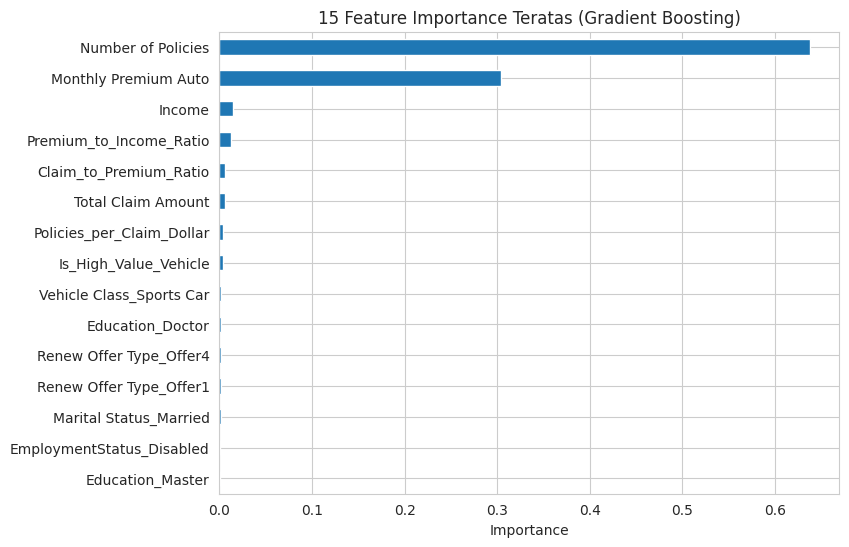

Number of Policies           0.637757
Monthly Premium Auto         0.304398
Income                       0.014624
Premium_to_Income_Ratio      0.012087
Claim_to_Premium_Ratio       0.006091
Total Claim Amount           0.005989
Policies_per_Claim_Dollar    0.003722
Is_High_Value_Vehicle        0.003523
Vehicle Class_Sports Car     0.001733
Education_Doctor             0.001596
Renew Offer Type_Offer4      0.001202
Renew Offer Type_Offer1      0.001184
Marital Status_Married       0.001122
EmploymentStatus_Disabled    0.000666
Education_Master             0.000535
dtype: float64


In [ ]:
# =========================================================
# 1. MENGAMBIL SELURUH NAMA FITUR (KOLOM) SETELAH PREPROCESSING
# =========================================================
# Karena variabel kategorikal telah diubah (misalnya via One-Hot Encoding),
# jumlah kolomnya bertambah. Kode ini menggabungkan nama fitur numerik dan fitur kategorikal yang baru diproses:
feature_names = (
    numeric_features +
    list(best_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)


# =========================================================
# 2. MENGECEK APAKAH MODEL MEMILIKI ATRIBUT 'feature_importances_'
# =========================================================
# Algoritma berbasis pohon (seperti Random Forest / Gradient Boosting) memiliki atribut 'feature_importances_'.
# hasattr() memeriksa apakah atribut tersebut ada pada model terbaik yang terpilih:
if hasattr(best_pipe.named_steps["model"], "feature_importances_"):

    # Mengambil nilai tingkat kepentingan (importance score) dari setiap fitur
    importances = best_pipe.named_steps["model"].feature_importances_

    # Membuat Series Pandas: Memasangkan nama fitur sebagai Indeks dan nilai Importance sebagai Data,
    # lalu mengurutkan dari yang paling penting (terbesar) dan mengambil 15 fitur teratas (.head(15))
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)


    # =========================================================
    # 3. VISUALISASI DIAGRAM BATANG HORISONTAL (BARH)
    # =========================================================
    plt.figure(figsize=(8,6)) # Menyiapkan kanvas gambar (ukuran 8x6 inci)
    feat_imp.plot(kind="barh") # Memplot grafik batang horizontal (ke samping kanan)
    plt.gca().invert_yaxis() # Membalik urutan sumbu Y agar fitur nomor #1 (paling penting) tampil di paling atas
    plt.title(f"15 Feature Importance Teratas ({best_name})") # Judul grafik dengan nama model
    plt.xlabel("Importance") # Memberi label pada sumbu X (nilai tingkat kepentingan)
    plt.show() # Menampilkan grafik ke layar

    print(feat_imp) # Mencetak angka pasti dari 15 fitur teratas tersebut
else:
    # Jika model terbaik adalah model linear (seperti Linear Regression/Ridge),
    # model tersebut tidak menggunakan 'feature_importances_' melainkan 'coef_' (koefisien).
    print("Model terbaik yang terpilih tidak memiliki feature_importances_ (misalnya Linear Regression) — lihat coefficients sebagai gantinya.")


## 9. Conclusion and Recommendation

### 9.1 Apakah Goal Tercapai?
Merujuk kembali ke Section 1.4: ya, model terbaik (lihat tabel Section 6.4) secara jelas mengungguli baseline mean-only pada ketiga metric, dan MAE-nya jauh lebih kecil dibanding standar deviasi CLV, mengonfirmasi bahwa model menangkap sinyal yang nyata dan bisa digunakan, bukan sekadar noise. Ini measurable, achievable, dan bisa langsung digunakan oleh stakeholder Marketing & Retention untuk **melakukan ranking pelanggan ke dalam tier nilai**.

### 9.2 Kapan Model Ini Bisa Dipercaya
- **Bisa dipercaya untuk:** ranking/segmentasi relatif pelanggan (misalnya "top 25% expected CLV") untuk memprioritaskan kampanye retensi ini tetap robust meskipun prediksi nilai dolar absolut kurang presisi.
- **Kurang bisa dipercaya untuk:** forecast nilai dolar yang presisi untuk pelanggan individual dengan CLV sangat tinggi, di mana Section 7 menunjukkan error cenderung paling besar *justru segmen yang paling penting untuk dijaga oleh bisnis*.

### 9.3 Business Impact
Dengan model ini, tim Marketing & Retention bisa beralih dari reaktif (baru mengetahui siapa yang bernilai tinggi setelah kejadian) menjadi **proaktif** dalam prioritisasi mengarahkan penawaran retensi, cross-sell, dan investasi loyalitas kepada pelanggan yang diprediksi bernilai tinggi sebelum nilai tersebut sepenuhnya terealisasi.

### 9.4 Limitasi
- **Limitasi data:** dataset ini tidak memiliki dimensi waktu (tidak ada tenure, tanggal mulai polis, atau histori renewal dari waktu ke waktu), sehingga model belum bisa memperhitungkan *bagaimana* CLV berkembang sepanjang siklus hidup pelanggan, model hanya memprediksi titik akhir yang statis.
- **Limitasi model:** seperti ditunjukkan di Section 7, error prediksi meningkat untuk pelanggan dengan CLV tertinggi, kemungkinan karena representasi mereka dalam data training lebih sedikit (target yang right-skewed).
- **Limitasi scope:** kita belum melakukan hyperparameter tuning atau mencoba varian gradient boosting lain seperti XGBoost/LightGBM, yang kemungkinan besar masih punya ruang untuk meningkatkan hasil ini lebih jauh.

### 9.5 Rekomendasi Langkah Selanjutnya
1. **Hyperparameter tuning** (GridSearchCV / RandomizedSearchCV) pada model terbaik untuk meningkatkan akurasi lebih lanjut.
2. **Mencoba XGBoost / LightGBM**, yang seringkali mengungguli Gradient Boosting bawaan sklearn pada data tabular seperti ini.
3. **Melatih model pada `log1p(CLV)`** dan membandingkan hasilnya berpotensi secara khusus meningkatkan akurasi pada segmen CLV tinggi yang teridentifikasi sebagai titik terlemah di Section 7.
4. **Menambahkan dimensi waktu** jika tersedia (tenure pelanggan, jumlah renewal dari waktu ke waktu) untuk beralih dari estimasi CLV yang statis menuju model trajectory lifetime yang sesungguhnya.
5. **Mengoperasionalkan sebagai tier, bukan nominal dolar eksak**, mengingat temuan di Section 7, sebaiknya model ini diimplementasikan sebagai tool segmentasi pelanggan (misalnya prioritas High/Medium/Low), bukan menampilkan angka CLV dolar yang eksak ke pihak bisnis.


10. Appendix: Save Model in Pickle

In [ ]:
import pickle

# ======================================================
# MENYIMPAN MODEL TERBAIK KE DALAM FILE (EXPORT / SAVE)
# ======================================================
# 'clv_model.pkl' adalah nama file tempat kita menyimpan model Machine Learning.
# 'wb' singkatan dari "Write Binary" -> artinya kita membuka/membuat file baru untuk DIISI dengan data biner.
with open("clv_model.pkl", "wb") as f:
    pickle.dump(best_pipe, f) # pickle.dump() bertugas membungkus dan menyimpan pipeline model terbaik (best_pipe) ke dalam file 'f'

In [ ]:
# ===============================================
# MEMUAT KEMBALI MODEL DARI FILE (IMPORT / LOAD)
# ===============================================
# 'rb' singkatan dari "Read Binary" -> artinya kita BUKA/BACA file biner yang tadi sudah disimpan.
with open("clv_model.pkl", "rb") as f:
    loaded_model = pickle.load(f) # pickle.load() bertugas membaca isi file dan merekonstruksi kembali objek model Machine Learning-nya

# =============================================================
# MENGGUNAKAN MODEL YANG SUDAH DILOAD UNTUK PREDIKSI DATA BARU
# =============================================================
# Kita menguji apakah model yang dimuat ulang berfungsi dengan baik untuk menebak nilai (X_test)
new_predictions = loaded_model.predict(X_test)